### INTRODUÇÃO
Qual o problema a ser resolvido?

Digamos que você foi contratado pela Spotify como um ciêntista de dados, e uma grande dor atual que eles possuem é de conseguir entender as características e comportamentos que as músicas dos artistas/bandas Top Artists causam em seus usuários.

Todo grande projeto de ciência de dados, nasce a partir de uma dor/problema a se resolver! Então após fazer o entendimento inicial sobre o projeto a ser desenvolvido e o ganho para a empresa, você começou a investigar em sua base de dados. E o primeiro caso que você decidiu a analisar é a famosa banda de rock Rolling Stones.

In [1]:
# Biblioteca
import pandas as pd

In [2]:
# Carregando o dataset
df = pd.read_excel("dataset_rolling_stones.xlsx")
df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106


In [3]:
# Informação das colunas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   name              1610 non-null   str           
 1   album             1610 non-null   str           
 2   release_date      1610 non-null   datetime64[us]
 3   track_number      1610 non-null   int64         
 4   acousticness      1610 non-null   float64       
 5   danceability      1610 non-null   float64       
 6   energy            1610 non-null   float64       
 7   instrumentalness  1610 non-null   float64       
 8   liveness          1610 non-null   float64       
 9   loudness          1610 non-null   float64       
 10  speechiness       1610 non-null   float64       
 11  tempo             1610 non-null   float64       
 12  valence           1610 non-null   float64       
 13  popularity        1610 non-null   int64         
 14  duration_ms       1610 non-null   i

In [4]:
# Quantidade de linhas e colunas
df.shape

(1610, 15)

In [5]:
# Data inicial da primeira música lançada
print("Data inicial: ", df["release_date"].min())

Data inicial:  1964-04-16 00:00:00


In [6]:
# Data da ultima música lançada
print("Data final: ", df["release_date"].max())

Data final:  2022-06-10 00:00:00


In [7]:
# Verificando se existem valores nulos
df.isnull().sum()

name                0
album               0
release_date        0
track_number        0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64

In [8]:
# Verificando linhas duplicadas
df.duplicated().sum()

np.int64(6)

In [9]:
# Listando as linhas duplicadas
df[df.duplicated()]

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
928,Some Girls - Remastered,Some Girls (Deluxe Version),1978-06-09,4,0.5270,0.474,0.938,0.520000,0.299,-2643.0,0.0898,71995.00,0.505,21,276933
929,Lies - Remastered,Some Girls (Deluxe Version),1978-06-09,5,0.4370,0.382,0.997,0.950000,0.617,-1568.0,0.1880,162428.00,0.563,16,191266
935,Claudine,Some Girls (Deluxe Version),1978-06-09,1,0.0144,0.439,0.977,0.022100,0.383,-4386.0,0.1280,105124.00,0.364,17,222253
939,No Spare Parts,Some Girls (Deluxe Version),1978-06-09,5,0.2400,0.594,0.762,0.000015,0.712,-5145.0,0.0292,72648.00,0.540,19,270466
940,Don't Be A Stranger,Some Girls (Deluxe Version),1978-06-09,6,0.0610,0.720,0.867,0.029700,0.385,-5871.0,0.0390,127329.00,0.847,15,246266
946,Petrol Blues,Some Girls (Deluxe Version),1978-06-09,12,0.7690,0.835,0.621,0.114000,0.116,-8007.0,0.0406,115.87,0.336,13,95626


In [10]:
df.describe() # Estatísticas descritivas para colunas numéricas

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920


In [11]:
# Convertendo duração de milissegundos para minutos
df["duracao_em_min"] = df["duration_ms"] / 60000 
df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100


In [12]:
df.describe()

,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min
count,1610,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,1992-04-23 12:57:14.534161,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6406.640075,0.069512,114078.725261,0.582165,20.788199,257736.488199,4.295608
min,1964-04-16 00:00:00,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24408.000000,0.023200,65.990000,0.000000,0.000000,21000.000000,0.350000
25%,1970-09-04 00:00:00,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8829.500000,0.036500,98996.500000,0.404250,13.000000,190613.000000,3.176883
50%,1986-03-24 00:00:00,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6179.000000,0.051200,120319.000000,0.583000,20.000000,243093.000000,4.051550
75%,2017-12-01 00:00:00,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4254.750000,0.086600,140853.750000,0.778000,27.000000,295319.750000,4.921996
max,2022-06-10 00:00:00,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-2.310000,0.624000,216304.000000,0.974000,80.000000,981866.000000,16.364433
std,NaN,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,3474.285941,0.051631,46196.602233,0.231253,12.426859,108333.474920,1.805558


In [13]:
# Agrupando por album e calculando a média da duração em minutos
df.groupby("album")["duracao_em_min"].mean()

album
12 X 5                              2.682068
12 x 5                              2.682772
A Bigger Bang (2009 Re-Mastered)    4.016356
A Bigger Bang (Live)                5.176630
Aftermath                           3.899185
                                      ...   
Undercover                          4.492750
Undercover (2009 Re-Mastered)       4.497595
Voodoo Lounge (Remastered 2009)     4.118779
Voodoo Lounge Uncut (Live)          5.248507
got LIVE if you want it!            2.762532
Name: duracao_em_min, Length: 90, dtype: float64

In [14]:
# Importando a biblioteca de visualização
import matplotlib.pyplot as plt

In [15]:
df_maior_duracao_musica = df.groupby("album")["duracao_em_min"].mean().sort_values(ascending=False)

In [16]:
df_maior_duracao_musica

album
Havana Moon (Live)                                                      6.632819
Bridges To Bremen (Live)                                                6.332265
Jamming With Edward                                                     6.042794
Live At The Checkerboard Lounge                                         6.009647
Totally Stripped - Paris (Live)                                         5.947430
                                                                          ...   
Out Of Our Heads (UK)                                                   2.464643
Out Of Our Heads (UK Sequence)                                          2.449274
December's Children (and everybody's)                                   2.408976
December’s Children (And Everybody’s)                                   2.408532
Live 1965: Music From Charlie Is My Darling (Live From England/1965)    2.146082
Name: duracao_em_min, Length: 90, dtype: float64

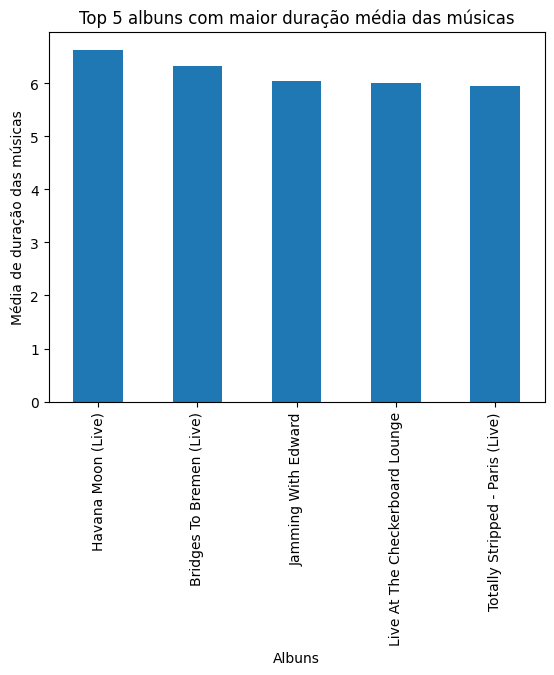

In [17]:
df_maior_duracao_musica.head(5).plot(kind="bar")
plt.xlabel("Albuns")
plt.ylabel("Média de duração das músicas")
plt.title("Top 5 albuns com maior duração média das músicas")
plt.show()

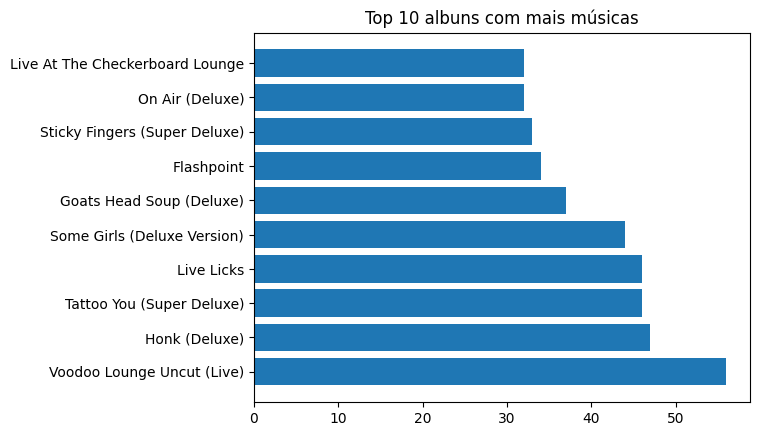

In [18]:
top_albuns = df['album'].value_counts().head(10)
plt.barh(top_albuns.index, top_albuns.values)# Gráfico de barras no horizontal
plt.title('Top 10 albuns com mais músicas')
plt.show()


In [19]:
top_albuns

album
Voodoo Lounge Uncut (Live)         56
Honk (Deluxe)                      47
Tattoo You (Super Deluxe)          46
Live Licks                         46
Some Girls (Deluxe Version)        44
Goats Head Soup (Deluxe)           37
Flashpoint                         34
Sticky Fingers (Super Deluxe)      33
On Air (Deluxe)                    32
Live At The Checkerboard Lounge    32
Name: count, dtype: int64

In [20]:
# Como anda a popularidade da banda nos ultimos tempos
df_ultima_decada = df[df["release_date"].between(pd.to_datetime("2011"), pd.to_datetime("2020"))]

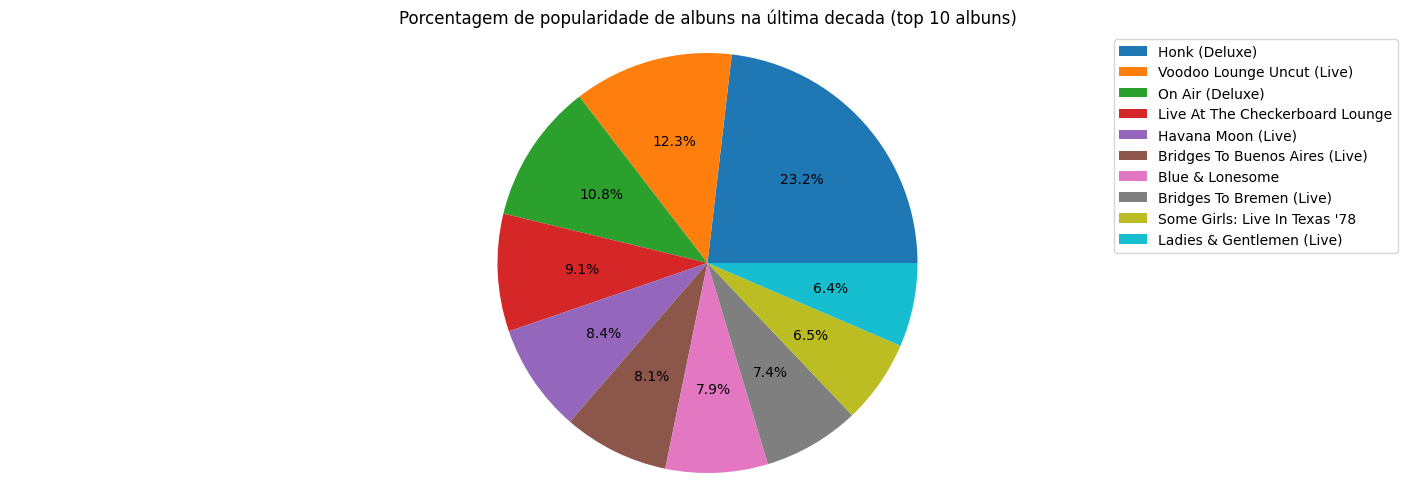

In [21]:
# Agrupando por album e somando a popularidade
df_por_album = df_ultima_decada.groupby("album")["popularity"].sum().sort_values(ascending=False).head(10)

total_popularidade = df_por_album.sum() # Somando a popularidade total dos 10 albuns mais populares

df_porcentagem = df_por_album / total_popularidade * 100 # Calculando a porcentagem de popularidade de cada album

labels = df_porcentagem.index.tolist() # Convertendo os rótulos para uma lista
sizes = df_porcentagem.values.tolist() # Convertendo os valores para uma lista

figura, grafico = plt.subplots(figsize=(18,6)) # Criando uma figura e um gráfico
grafico.pie(sizes, autopct="%1.1f%%") # Criando um gráfico de pizza com as porcentagens
grafico.axis('equal') # Garantindo que o gráfico seja circular
plt.title("Porcentagem de popularidade de albuns na última decada (top 10 albuns)") # Titulo do gráfico
plt.legend(labels, loc="best")

plt.show()

In [22]:
# Instalando o seaborn
%pip install seaborn

# Importando a biblioteca de visualização
import seaborn as sns # Muito bom pra visualizar os outliers


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


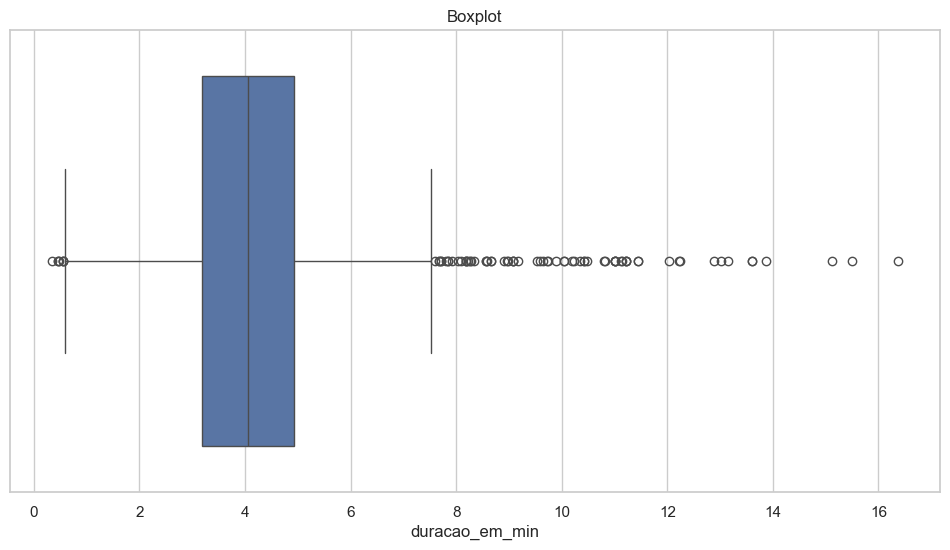

In [23]:
sns.set(style="whitegrid")  # Configurando o estilo do gráfico
fig, axes = plt.subplots(figsize=(12,6)) # Criando uma figura e um gráfico
sns.boxplot(x="duracao_em_min", data=df) # Criando um boxplot para a coluna "duracao_em_min"
axes.set_title("Boxplot") # Titulo do gráfico
plt.show()

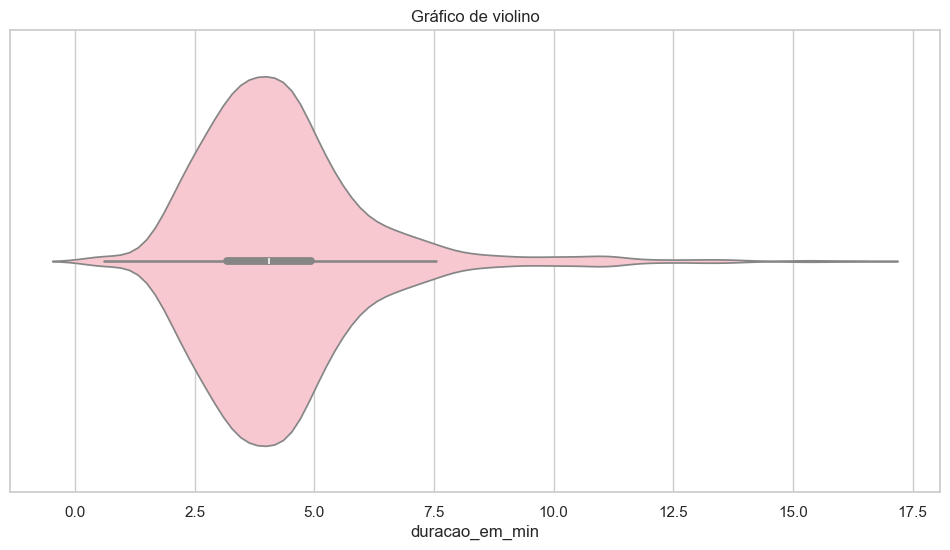

In [24]:
fig, axes = plt.subplots(figsize=(12,6)) # Criando uma figura e um gráfico
sns.violinplot(x="duracao_em_min", data=df, color="pink") # Criando o gráfico de violino
axes.set_title("Gráfico de violino")
plt.show()

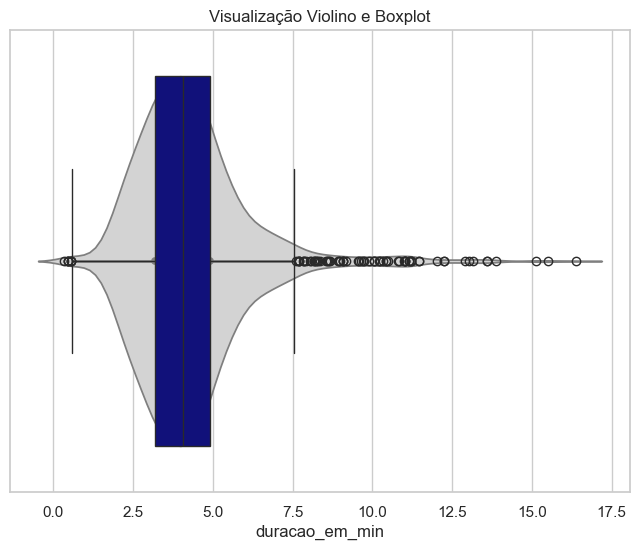

In [25]:
fig, ax = plt.subplots(figsize=(8,6))

sns.violinplot(x="duracao_em_min", data=df, ax= ax, color="lightgray")
sns.boxplot(x="duracao_em_min", data=df, ax=ax, whis=1.5, color="darkblue")

ax.set_title("Visualização Violino e Boxplot")
plt.show()


In [26]:
# Criando uma função para classificar se a música é ao vivo ou não
def classifica_musica_ao_vivo(df):
    if df["liveness"] >= 0.8:
        return True
    else:
        return False

In [27]:
# Criando coluna "ao_vivo" aplicando a função de classificação
df["ao_vivo"] = df.apply(classifica_musica_ao_vivo, axis=1)

df.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996000,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233000,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True
2,Start Me Up - Live,Licked Live In NYC,2022-06-10,3,0.4160,0.386,0.969,0.400000,0.956,-4936.0,0.1150,130066.0,0.3130,34,263160,4.386000,True
3,If You Can't Rock Me - Live,Licked Live In NYC,2022-06-10,4,0.5670,0.369,0.985,0.000107,0.895,-5535.0,0.1930,132994.0,0.1470,32,305880,5.098000,True
4,Don’t Stop - Live,Licked Live In NYC,2022-06-10,5,0.4000,0.303,0.969,0.055900,0.966,-5098.0,0.0930,130533.0,0.2060,32,305106,5.085100,True


In [28]:
# Fazendo uma contagem pra saber a quantidade de musicas que temos ao vivo
df.groupby("ao_vivo")["ao_vivo"].count()

ao_vivo
False    1112
True      498
Name: ao_vivo, dtype: int64

In [29]:
# Separando as músicas ao vivo das de estúdio
df_gravado_em_studio = df[df["ao_vivo"] == False]
df_show_ao_vivo = df[df["ao_vivo"] == True]

df_gravado_em_studio.head()

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo
5,Monkey Man - Live,Licked Live In NYC,2022-06-10,6,0.2750,0.340,0.956,0.12500,0.741,-5539.0,0.0915,101628.0,0.125,31,244293,4.071550,False
23,Honky Tonk Women - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,1,0.1620,0.430,0.901,0.01100,0.694,-6215.0,0.0450,112077.0,0.890,32,216546,3.609100,False
25,Hand Of Fate - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,3,0.0654,0.477,0.899,0.03760,0.727,-6189.0,0.0425,129991.0,0.805,29,267866,4.464433,False
26,Route 66 - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,4,0.0975,0.473,0.923,0.00157,0.722,-6204.0,0.0791,144625.0,0.792,30,193653,3.227550,False
28,Crazy Mama - Live At The El Mocambo 1977,Live At The El Mocambo,2022-05-13,6,0.0288,0.447,0.883,0.00554,0.726,-6266.0,0.0371,117604.0,0.556,29,299213,4.986883,False


In [30]:
# Verificando a média de músicas ao vivo
print("Média das músicas ao vivo:", df_show_ao_vivo["duracao_em_min"].mean())

Média das músicas ao vivo: 5.088648962516734


In [31]:
print("Média das músicas em studio:", df_gravado_em_studio["duracao_em_min"].mean())

Média das músicas em studio: 3.940451363908873


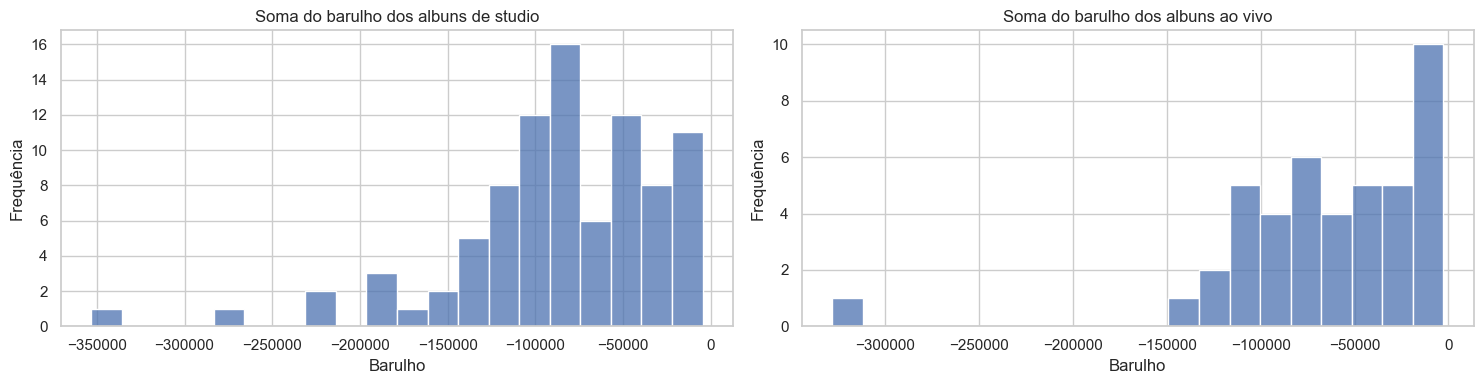

In [32]:
# Histograma: Analisar os dados contínuos, como a duração das músicas, para entender a distribuição dos dados e identificar possíveis padrões ou 
# anomalias
# Questão: As músicas do Rolling Stone é muito barulhenta?
df_studio = df_gravado_em_studio.groupby("album")["loudness"].sum()
df_ao_vivo = df_show_ao_vivo.groupby("album")["loudness"].sum()

# Criando gráficos de histograma
fig, axes = plt.subplots(1, 2, figsize=(15,4)) # Criando uma figura com 2 gráficos lado a lado

sns.histplot(data=df_studio, bins=20, ax=axes[0])
axes[0].set_title("Soma do barulho dos albuns de studio")
axes[0].set_xlabel("Barulho")
axes[0].set_ylabel("Frequência")


sns.histplot(data=df_ao_vivo, bins=20, ax=axes[1])
axes[1].set_title("Soma do barulho dos albuns ao vivo")
axes[1].set_xlabel("Barulho")
axes[1].set_ylabel("Frequência")

fig.tight_layout()
plt.show()


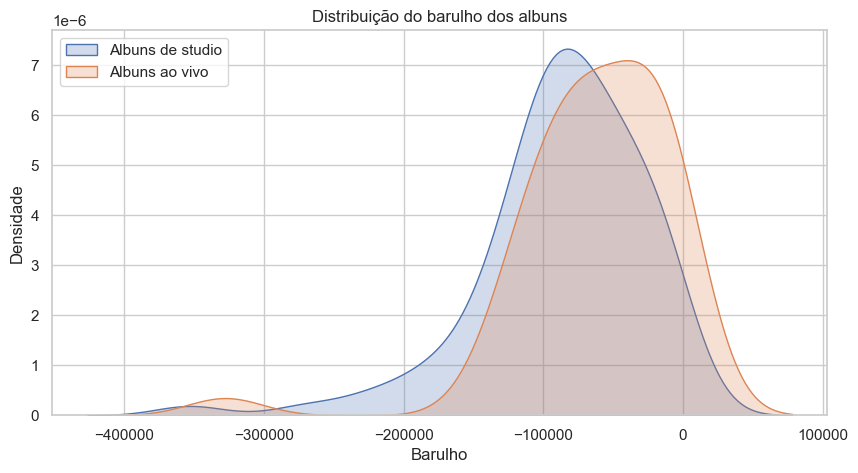

In [33]:
# Gráfico de Densidade
plt.figure(figsize=(10,5))

sns.kdeplot(data=df_studio, label="Albuns de studio", fill= True)
sns.kdeplot(data=df_ao_vivo, label="Albuns ao vivo", fill= True)

plt.title("Distribuição do barulho dos albuns")
plt.xlabel("Barulho")
plt.ylabel("Densidade")
plt.legend()


### Aprendendo a usar testes estatísticos

In [34]:
from scipy.stats import shapiro

In [35]:
# Teste de normalidade para os dados dos albuns de studio
stat, p = shapiro(df_studio)
print("Soma do barulho dos albuns do studio: ")
print("Estatística de teste: {:.4f}, valor p:{}".format(stat, p))

if p > 0.05:
    print("Os dados seguem uma distribuição normal")
else:    
    print("Os dados NÃO seguem uma distribuição normal")

Soma do barulho dos albuns do studio: 
Estatística de teste: 0.8958, valor p:3.2961810837731026e-06
Os dados NÃO seguem uma distribuição normal


In [36]:
from scipy.stats import mannwhitneyu

In [37]:
# Teste de Mann-Whitney U para comparar as distribuições dos barulhos dos albuns de studio e ao vivo
stat, p=mannwhitneyu(df_studio.sample(len(df_studio)), df_ao_vivo.sample(len(df_ao_vivo)), alternative="less")

print("Estatística de teste U: ", stat)
print("Valor p:", p)

alpha = 0.05
if p < alpha:
    print("Diferença estatisticamente significante")
else:
    print("Não há diferença estatisticamente significante")

Estatística de teste U:  1367.0
Valor p: 0.0050727361177996585
Diferença estatisticamente significante


### Correlação

In [38]:
# Analisando a valência média por album
media_por_album = df.groupby("album")["valence"].mean().reset_index()

media_por_album = media_por_album.rename(columns={"valence": "media_valence"})

media_por_album["sentimento"] = ["positivo" if v > 0.6 else "negativo" for v in media_por_album["media_valence"]]

media_por_album.groupby("sentimento")["sentimento"].count()

sentimento
negativo    38
positivo    52
Name: sentimento, dtype: int64

In [39]:
media_por_album.head(2)

,album,media_valence,sentimento
0,12 X 5,0.704000,positivo
1,12 x 5,0.689917,positivo


In [40]:
# Fazendo uma matriz de correlação
df_resultado_final = pd.merge(df, media_por_album, on="album")
df_resultado_final.head(2)

,name,album,release_date,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,duracao_em_min,ao_vivo,media_valence,sentimento
0,Concert Intro Music - Live,Licked Live In NYC,2022-06-10,1,0.0824,0.463,0.993,0.996,0.932,-12913.0,0.1100,118001.0,0.0302,33,48640,0.810667,True,0.27117,negativo
1,Street Fighting Man - Live,Licked Live In NYC,2022-06-10,2,0.4370,0.326,0.965,0.233,0.961,-4803.0,0.0759,131455.0,0.3180,34,253173,4.219550,True,0.27117,negativo


In [41]:
matriz_correlacao = df_resultado_final.corr(numeric_only=True)

correlacao_sentimento = matriz_correlacao["media_valence"]

display(correlacao_sentimento)

track_number       -0.115007
acousticness        0.015491
danceability        0.492945
energy             -0.347447
instrumentalness    0.133741
liveness           -0.571749
loudness           -0.229543
speechiness        -0.416005
tempo              -0.028887
valence             0.603258
popularity          0.100509
duration_ms        -0.309499
duracao_em_min     -0.309499
ao_vivo            -0.549736
media_valence       1.000000
Name: media_valence, dtype: float64

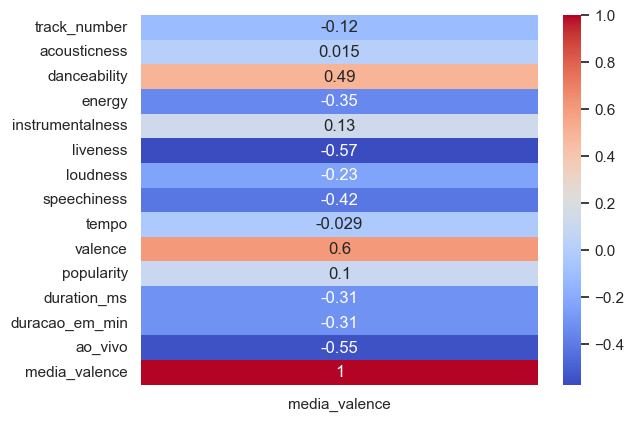

In [ ]:
# Mapa de calor para visualizar a correlação entre a valência média e as outras variáveis numéricas
sns.heatmap(correlacao_sentimento.to_frame(), annot=True, cmap = "coolwarm")
plt.show()

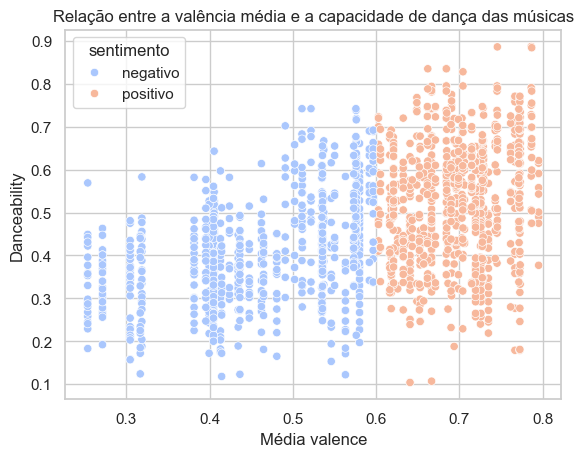

In [ ]:
# Análise de dispersão para visualizar a relação entre a valência média e a capacidade de dança das músicas, 
# colorindo os pontos de acordo com o sentimento (positivo ou negativo)
sns.scatterplot(x="media_valence", y="danceability", hue="sentimento", data=df_resultado_final, palette="coolwarm")

plt.xlabel("Média valence")
plt.ylabel("Danceability")
plt.title("Relação entre a valência média e a capacidade de dança das músicas")
plt.show()

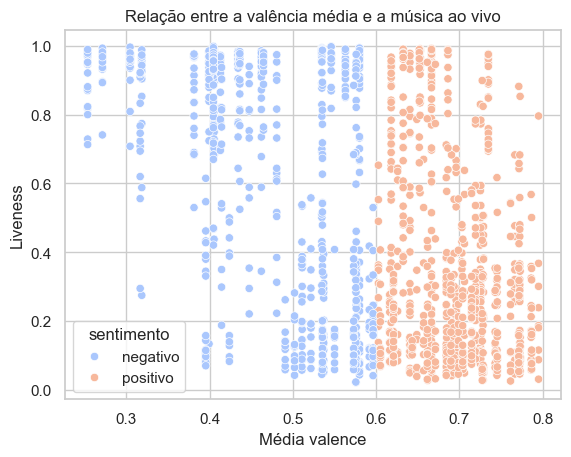

In [ ]:
# Análise de dispersão para visualizar a relação entre a valência média e a música ao vivo,
# colorindo os pontos de acordo com o sentimento (positivo ou negativo)
sns.scatterplot(x="media_valence", y="liveness", hue="sentimento", data=df_resultado_final, palette="coolwarm")
plt.xlabel("Média valence")
plt.ylabel("Liveness")
plt.title("Relação entre a valência média e a música ao vivo")
plt.show()